# Employee Attrition Prediction

## Employee Attrition Analysis using Python and Machine Learning

### Objective

The objective of this project is to analyze employee data, identify the key factors associated with employee attrition, and develop a machine learning model to predict whether an employee is likely to leave the organization.

### Target Variable

**Attrition**

- `Yes` → Employee left the organization
- `No` → Employee remained with the organization

In [169]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

df = pd.read_csv(
    r"C:\Users\himan\Documents\Employee Attrition System\WA_Fn-UseC_-HR-Employee-Attrition.csv"
)

df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2


In [170]:
df.shape

(1470, 35)

In [171]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [172]:
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,MonthlyRate,NumCompaniesWorked,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,2.728571,6502.931293,14313.103401,2.693197,15.209524,3.153741,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,1.102846,4707.956783,7117.786044,2.498009,3.659938,0.360824,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,1.000000,1009.000000,2094.000000,0.000000,11.000000,3.000000,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,2.000000,2911.000000,8047.000000,1.000000,12.000000,3.000000,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,3.000000,4919.000000,14235.500000,2.000000,14.000000,3.000000,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,4.000000,8379.000000,20461.500000,4.000000,18.000000,3.000000,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,4.000000,19999.000000,26999.000000,9.000000,25.000000,4.000000,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [173]:
df.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [174]:
df.duplicated().sum()

0

In [175]:
df["Attrition"].value_counts()

Attrition
No     1233
Yes     237
Name: count, dtype: int64

In [176]:
df["Attrition"].value_counts(normalize=True)*100

Attrition
No     83.877551
Yes    16.122449
Name: proportion, dtype: float64

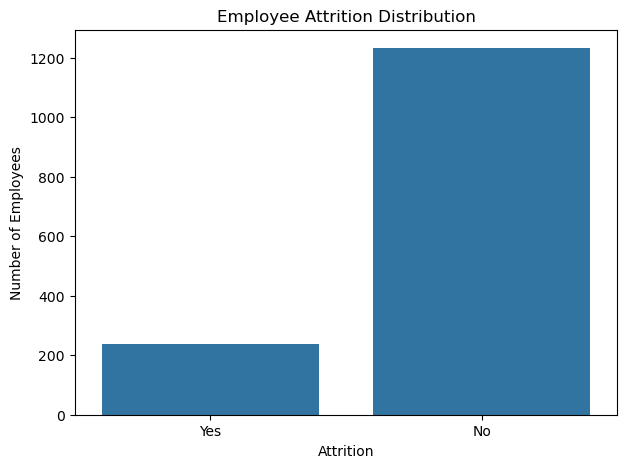

In [177]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="Attrition")

plt.title("Employee Attrition Distribution")
plt.xlabel("Attrition")
plt.ylabel("Number of Employees")

plt.show()

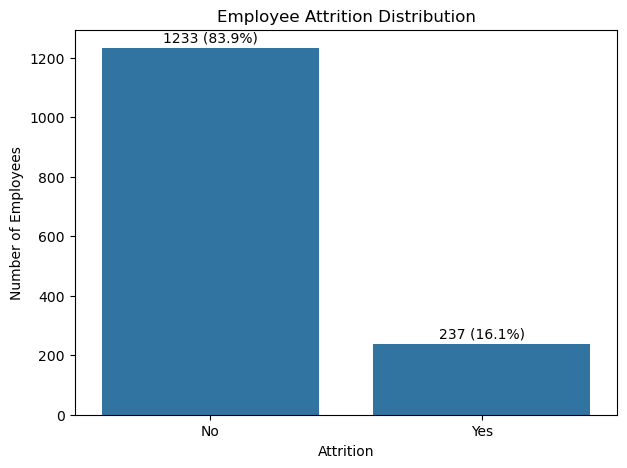

In [178]:
attrition_counts = df["Attrition"].value_counts()

plt.figure(figsize=(7, 5))

ax = sns.barplot(
    x=attrition_counts.index,
    y=attrition_counts.values
)

plt.title("Employee Attrition Distribution")
plt.xlabel("Attrition")
plt.ylabel("Number of Employees")

for i, value in enumerate(attrition_counts.values):
    percentage = value / len(df) * 100
    ax.text(i, value + 20, f"{value} ({percentage:.1f}%)",
            ha="center")

plt.show()

In [179]:
attrition_overtime = pd.crosstab(
    df["OverTime"],
    df["Attrition"],
    normalize="index"
) * 100

attrition_overtime

Attrition,No,Yes
OverTime,,
No,89.563567,10.436433
Yes,69.471154,30.528846


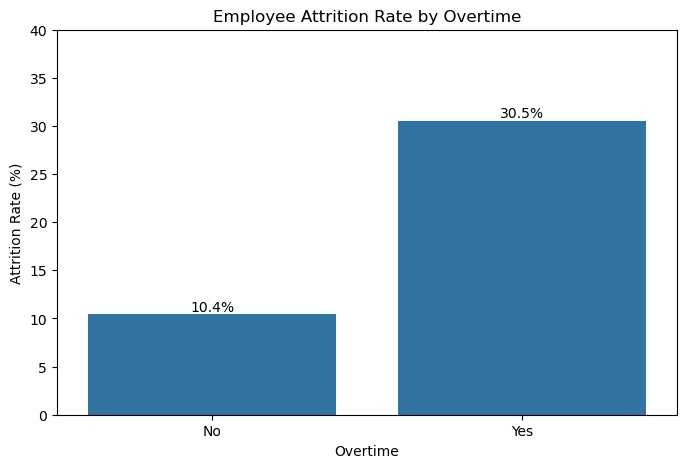

In [180]:
plt.figure(figsize=(8, 5))

attrition_rate = (
    df.groupby("OverTime")["Attrition"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .reset_index(name="AttritionRate")
)

ax = sns.barplot(
    data=attrition_rate,
    x="OverTime",
    y="AttritionRate"
)

plt.title("Employee Attrition Rate by Overtime")
plt.xlabel("Overtime")
plt.ylabel("Attrition Rate (%)")

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.ylim(0, 40)

plt.show()

## Insight: Overtime and Employee Attrition

Employees who work overtime show a significantly higher attrition rate than employees who do not.

- Employees working overtime: **30.5% attrition**
- Employees not working overtime: **10.4% attrition**

This indicates that overtime may be an important factor associated with employee turnover. Organizations could investigate workload distribution, employee burnout, and work-life balance when developing retention strategies.

In [182]:
job_role_attrition = (
    df.groupby("JobRole")["Attrition"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .sort_values(ascending=False)
    .reset_index(name="AttritionRate")
)

job_role_attrition

,JobRole,AttritionRate
0,Sales Representative,39.759036
1,Laboratory Technician,23.938224
2,Human Resources,23.076923
3,Sales Executive,17.484663
4,Research Scientist,16.095890
5,Manufacturing Director,6.896552
6,Healthcare Representative,6.870229
7,Manager,4.901961
8,Research Director,2.500000


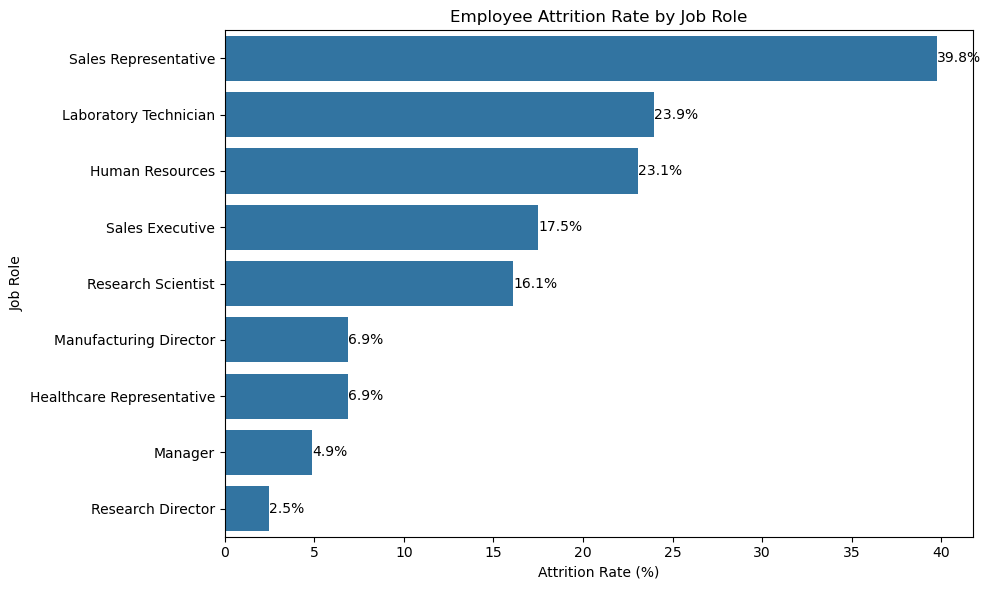

In [183]:
plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=job_role_attrition,
    x="AttritionRate",
    y="JobRole"
)

plt.title("Employee Attrition Rate by Job Role")
plt.xlabel("Attrition Rate (%)")
plt.ylabel("Job Role")

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.tight_layout()
plt.show()

## Insight: Job Role and Employee Attrition

Attrition varies considerably across job roles.

- **Sales Representatives** have the highest attrition rate at **39.8%**.
- **Laboratory Technicians** have the second-highest rate at **23.9%**.
- **Human Resources** follows at **23.1%**.
- **Research Directors** have the lowest attrition rate at **2.5%**.

The large variation suggests that employee retention may differ substantially by job role. Organizations could investigate workload, career growth, compensation, and job satisfaction within high-attrition roles.

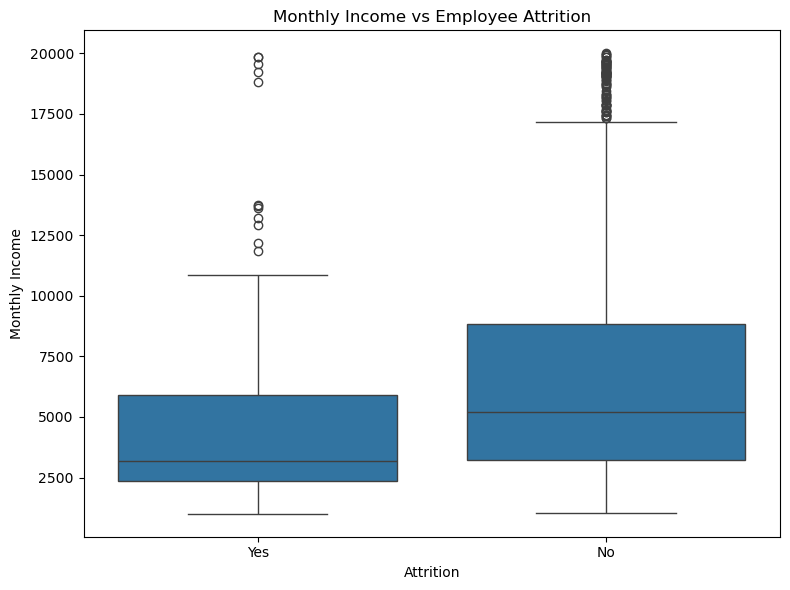

In [185]:
plt.figure(figsize=(8, 6))

sns.boxplot(
    data=df,
    x="Attrition",
    y="MonthlyIncome"
)

plt.title("Monthly Income vs Employee Attrition")
plt.xlabel("Attrition")
plt.ylabel("Monthly Income")

plt.tight_layout()
plt.show()

In [186]:
df.groupby("Attrition")["MonthlyIncome"].agg(
    ["mean", "median", "min", "max"]
)

,mean,median,min,max
Attrition,,,,
No,6832.739659,5204.0,1051,19999
Yes,4787.092827,3202.0,1009,19859


## Insight: Monthly Income and Employee Attrition

Employees who left the organization generally had lower monthly income than employees who stayed.

- Employees who stayed: **Mean = 6,832.74**, **Median = 5,204**
- Employees who left: **Mean = 4,787.09**, **Median = 3,202**

The difference suggests that compensation may be associated with employee attrition. However, income should not be considered the sole cause of attrition because other factors such as overtime, job role, career growth, and job satisfaction may also influence employee decisions.

In [188]:
age_attrition = (
    df.groupby("Attrition")["Age"]
    .agg(["mean", "median", "min", "max"])
)

age_attrition

,mean,median,min,max
Attrition,,,,
No,37.561233,36.0,18,60
Yes,33.607595,32.0,18,58


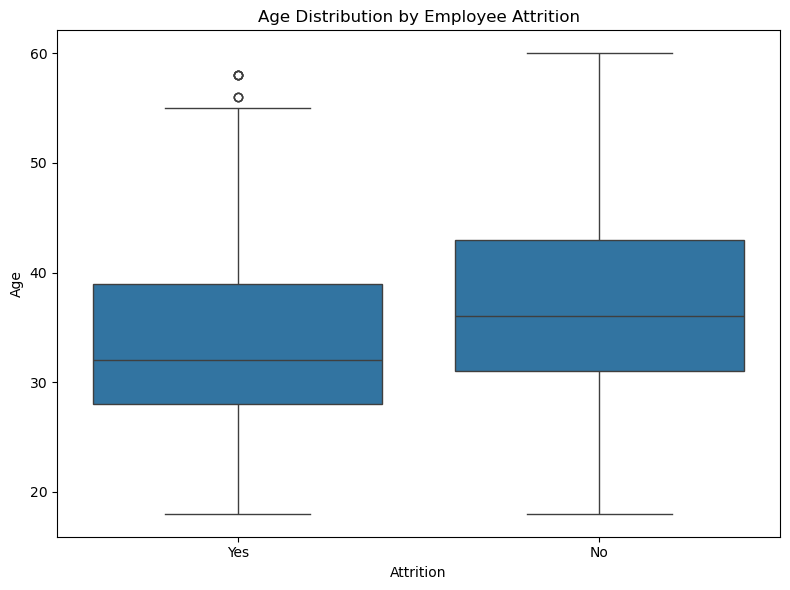

In [189]:
plt.figure(figsize=(8, 6))

sns.boxplot(
    data=df,
    x="Attrition",
    y="Age"
)

plt.title("Age Distribution by Employee Attrition")
plt.xlabel("Attrition")
plt.ylabel("Age")

plt.tight_layout()
plt.show()

## Insight: Age and Employee Attrition

Employees who left the organization were generally younger than employees who stayed.

- Employees who stayed: **Mean age = 37.56 years**, **Median = 36 years**
- Employees who left: **Mean age = 33.61 years**, **Median = 32 years**

This suggests that younger employees may have a higher tendency to leave the organization. However, age alone does not explain attrition and should be considered alongside factors such as career growth, compensation, job role, and job satisfaction.

In [191]:
job_satisfaction_attrition = pd.crosstab(
    df["JobSatisfaction"],
    df["Attrition"],
    normalize="index"
) * 100

job_satisfaction_attrition

Attrition,No,Yes
JobSatisfaction,,
1,77.162630,22.837370
2,83.571429,16.428571
3,83.484163,16.515837
4,88.671024,11.328976


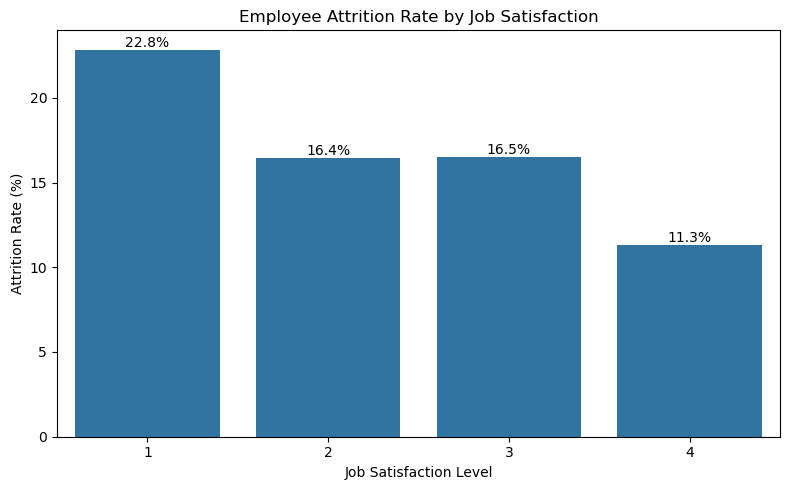

In [192]:
plt.figure(figsize=(8, 5))

attrition_rate = (
    df.groupby("JobSatisfaction")["Attrition"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .reset_index(name="AttritionRate")
)

ax = sns.barplot(
    data=attrition_rate,
    x="JobSatisfaction",
    y="AttritionRate"
)

plt.title("Employee Attrition Rate by Job Satisfaction")
plt.xlabel("Job Satisfaction Level")
plt.ylabel("Attrition Rate (%)")

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.tight_layout()
plt.show()

## Insight: Job Satisfaction and Employee Attrition

Job satisfaction shows a noticeable relationship with employee attrition.

- Employees with **Job Satisfaction = 1** have the highest attrition rate at **22.8%**.
- Satisfaction levels **2 and 3** have similar attrition rates of approximately **16.4%–16.5%**.
- Employees with **Job Satisfaction = 4** have the lowest attrition rate at **11.3%**.

The results suggest that lower job satisfaction is associated with higher employee attrition. Organizations could focus on improving employee experience, workplace conditions, recognition, and career development to support retention.

In [194]:
tenure_attrition = (
    df.groupby("Attrition")["YearsAtCompany"]
    .agg(["mean", "median", "min", "max"])
)

tenure_attrition

,mean,median,min,max
Attrition,,,,
No,7.369019,6.0,0,37
Yes,5.130802,3.0,0,40


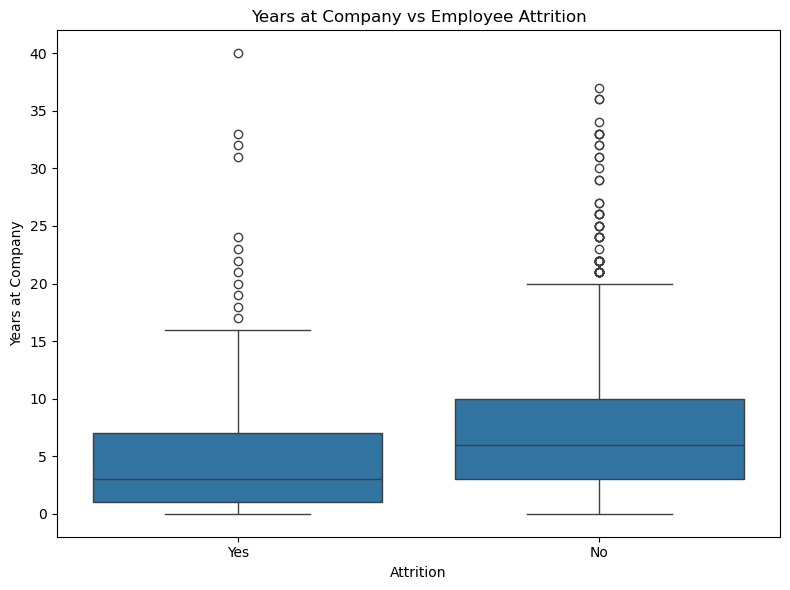

In [195]:
plt.figure(figsize=(8, 6))

sns.boxplot(
    data=df,
    x="Attrition",
    y="YearsAtCompany"
)

plt.title("Years at Company vs Employee Attrition")
plt.xlabel("Attrition")
plt.ylabel("Years at Company")

plt.tight_layout()
plt.show()

## Insight: Years at Company and Employee Attrition

Employees who left the organization generally had shorter tenure than employees who stayed.

- Employees who stayed: **Mean = 7.37 years**, **Median = 6 years**
- Employees who left: **Mean = 5.13 years**, **Median = 3 years**

The results suggest that employees with shorter tenure may be more likely to leave the organization. This may indicate the importance of effective onboarding, early-career development, employee engagement, and retention strategies.

In [197]:
joblevel_attrition = (
    df.groupby("JobLevel")["Attrition"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .reset_index(name="AttritionRate")
)

joblevel_attrition

,JobLevel,AttritionRate
0,1,26.335175
1,2,9.737828
2,3,14.678899
3,4,4.716981
4,5,7.246377


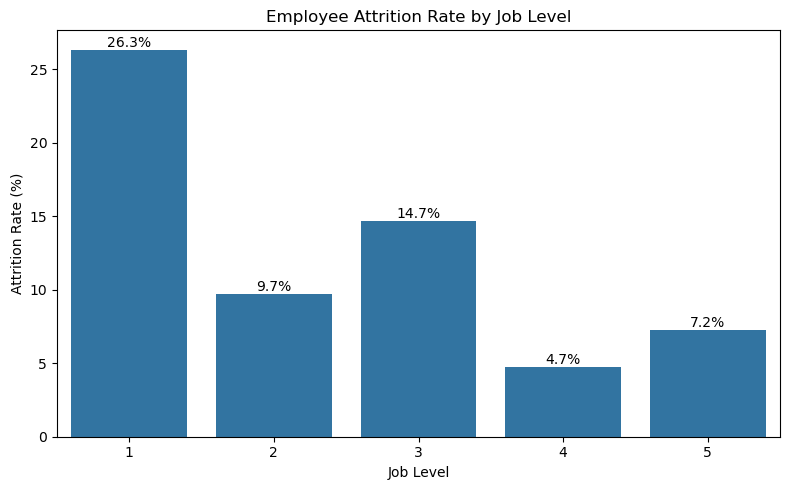

In [198]:
plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=joblevel_attrition,
    x="JobLevel",
    y="AttritionRate"
)

plt.title("Employee Attrition Rate by Job Level")
plt.xlabel("Job Level")
plt.ylabel("Attrition Rate (%)")

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.tight_layout()
plt.show()

## Insight: Job Level and Employee Attrition

Employee attrition varies considerably across job levels.

- **Job Level 1** has the highest attrition rate at **26.3%**.
- **Job Level 3** has the second-highest rate at **14.7%**.
- **Job Level 4** has the lowest attrition rate at **4.7%**.
- Job Levels 2 and 5 have relatively lower attrition rates of **9.7%** and **7.2%**, respectively.

The higher attrition at lower job levels may indicate that early-career employees are more likely to leave. Factors such as career progression, compensation, workload, and job satisfaction may be important areas for further investigation.

In [200]:
travel_attrition = (
    df.groupby("BusinessTravel")["Attrition"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .reset_index(name="AttritionRate")
)

travel_attrition

,BusinessTravel,AttritionRate
0,Non-Travel,8.000000
1,Travel_Frequently,24.909747
2,Travel_Rarely,14.956855


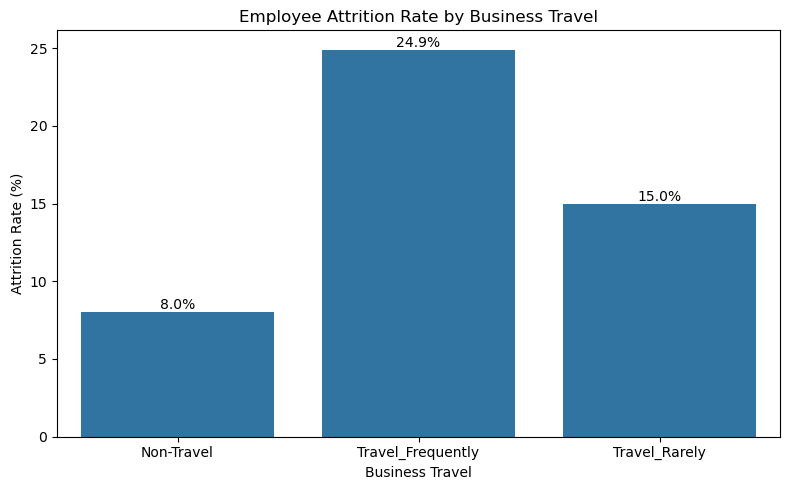

In [201]:
plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=travel_attrition,
    x="BusinessTravel",
    y="AttritionRate"
)

plt.title("Employee Attrition Rate by Business Travel")
plt.xlabel("Business Travel")
plt.ylabel("Attrition Rate (%)")

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.tight_layout()
plt.show()

## Insight: Business Travel and Employee Attrition

Business travel shows a noticeable relationship with employee attrition.

- Employees who **travel frequently** have the highest attrition rate at **24.9%**.
- Employees who **travel rarely** have an attrition rate of **15.0%**.
- Employees who **do not travel** have the lowest attrition rate at **8.0%**.

The results suggest that frequent business travel may be associated with higher employee attrition. Organizations could investigate travel workload, work-life balance, and employee support for frequently traveling employees.

In [203]:
distance_attrition = (
    df.groupby("Attrition")["DistanceFromHome"]
    .agg(["mean", "median", "min", "max"])
)

distance_attrition

,mean,median,min,max
Attrition,,,,
No,8.915653,7.0,1,29
Yes,10.632911,9.0,1,29


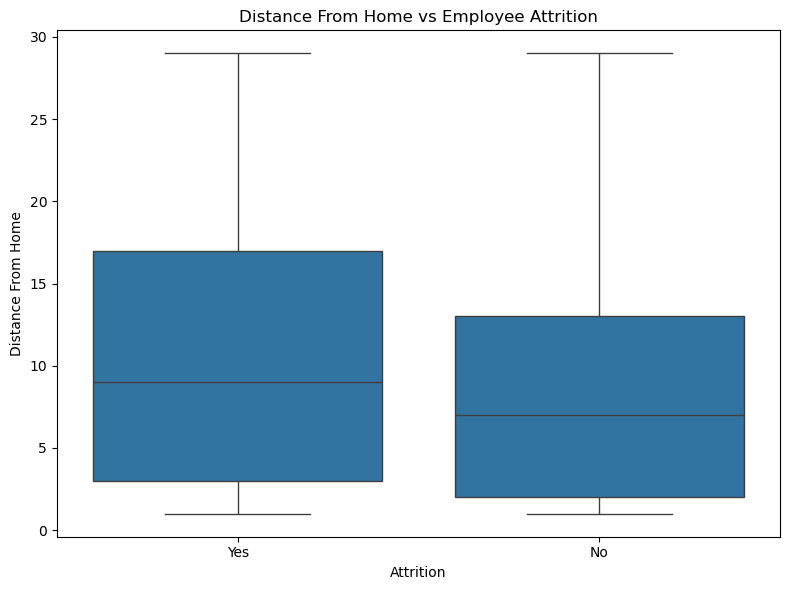

In [204]:
plt.figure(figsize=(8, 6))

sns.boxplot(
    data=df,
    x="Attrition",
    y="DistanceFromHome"
)

plt.title("Distance From Home vs Employee Attrition")
plt.xlabel("Attrition")
plt.ylabel("Distance From Home")

plt.tight_layout()
plt.show()

## Insight: Distance From Home and Employee Attrition

Employees who left the organization generally had a greater distance from home than employees who stayed.

- Employees who stayed: **Mean = 8.92**, **Median = 7**
- Employees who left: **Mean = 10.63**, **Median = 9**

The results indicate a possible association between commuting distance and employee attrition. However, distance from home alone does not establish a causal relationship and should be considered alongside other workplace and personal factors.

In [206]:
environment_attrition = (
    df.groupby("EnvironmentSatisfaction")["Attrition"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .reset_index(name="AttritionRate")
)

environment_attrition

,EnvironmentSatisfaction,AttritionRate
0,1,25.352113
1,2,14.982578
2,3,13.686534
3,4,13.452915


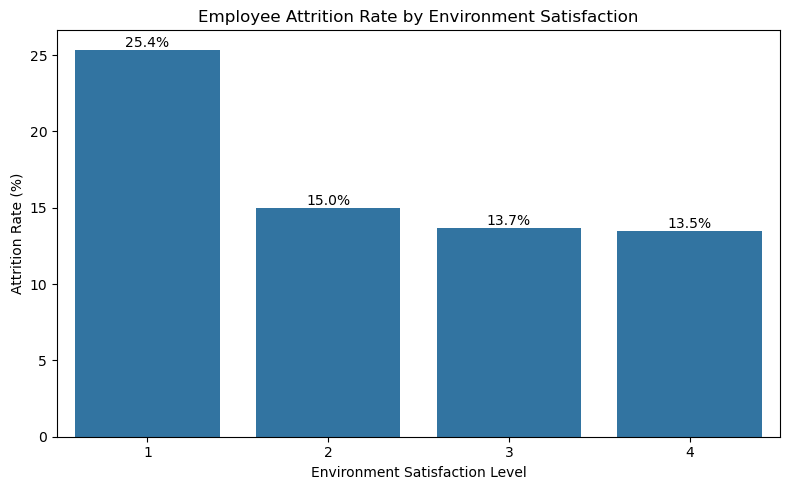

In [207]:
plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=environment_attrition,
    x="EnvironmentSatisfaction",
    y="AttritionRate"
)

plt.title("Employee Attrition Rate by Environment Satisfaction")
plt.xlabel("Environment Satisfaction Level")
plt.ylabel("Attrition Rate (%)")

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.tight_layout()
plt.show()

In [208]:
# Separate target variable and features

X = df.drop("Attrition", axis=1)
y = df["Attrition"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (1470, 34)
Target shape: (1470,)


In [209]:
# Convert Attrition into binary values

y = y.map({"No": 0, "Yes": 1})

print(y.value_counts())

Attrition
0    1233
1     237
Name: count, dtype: int64


In [210]:
# Identify categorical and numerical features

categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()
numerical_cols = X.select_dtypes(exclude=["object"]).columns.tolist()

print("Categorical Columns:")
print(categorical_cols)

print("\nNumerical Columns:")
print(numerical_cols)

Categorical Columns:
['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'Over18', 'OverTime']

Numerical Columns:
['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


In [211]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in categorical_cols:
    X[col] = le.fit_transform(X[col])

In [212]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape, X_test.shape)

(1176, 34) (294, 34)


In [213]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [214]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [215]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [216]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

In [217]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

def evaluate_model(y_test, y_pred, model_name):
    print(f"\n🔹 {model_name}")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("Classification Report:\n", classification_report(y_test, y_pred))

evaluate_model(y_test, y_pred_lr, "Logistic Regression")
evaluate_model(y_test, y_pred_rf, "Random Forest")
evaluate_model(y_test, y_pred_dt, "Decision Tree")


🔹 Logistic Regression
Accuracy: 0.891156462585034
Confusion Matrix:
 [[249   6]
 [ 26  13]]
Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.98      0.94       255
           1       0.68      0.33      0.45        39

    accuracy                           0.89       294
   macro avg       0.79      0.65      0.69       294
weighted avg       0.88      0.89      0.87       294


🔹 Random Forest
Accuracy: 0.8639455782312925
Confusion Matrix:
 [[250   5]
 [ 35   4]]
Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.98      0.93       255
           1       0.44      0.10      0.17        39

    accuracy                           0.86       294
   macro avg       0.66      0.54      0.55       294
weighted avg       0.82      0.86      0.83       294


🔹 Decision Tree
Accuracy: 0.7653061224489796
Confusion Matrix:
 [[218  37]
 [ 32   7]]
Classification Report:
      

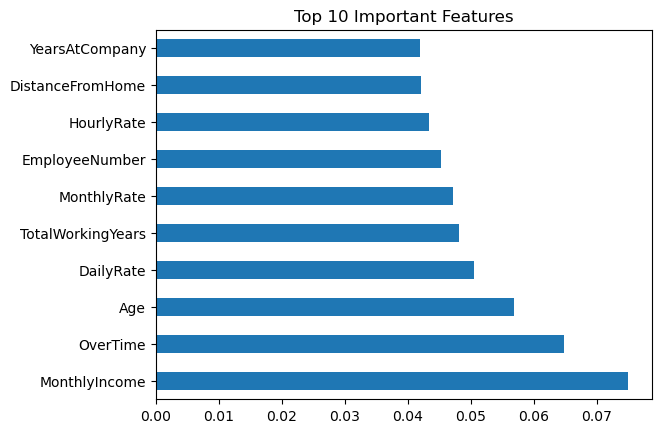

In [218]:
import pandas as pd
import matplotlib.pyplot as plt

feature_importance = pd.Series(rf.feature_importances_, index=X.columns)
feature_importance.nlargest(10).plot(kind='barh')

plt.title("Top 10 Important Features")
plt.show()

In [219]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

models = {
    "Logistic Regression": y_pred_lr,
    "Random Forest": y_pred_rf,
    "Decision Tree": y_pred_dt
}

results = []

for name, pred in models.items():
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred),
        "Recall": recall_score(y_test, pred),
        "F1 Score": f1_score(y_test, pred)
    })

results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.891156,0.684211,0.333333,0.448276
1,Random Forest,0.863946,0.444444,0.102564,0.166667
2,Decision Tree,0.765306,0.159091,0.179487,0.168675


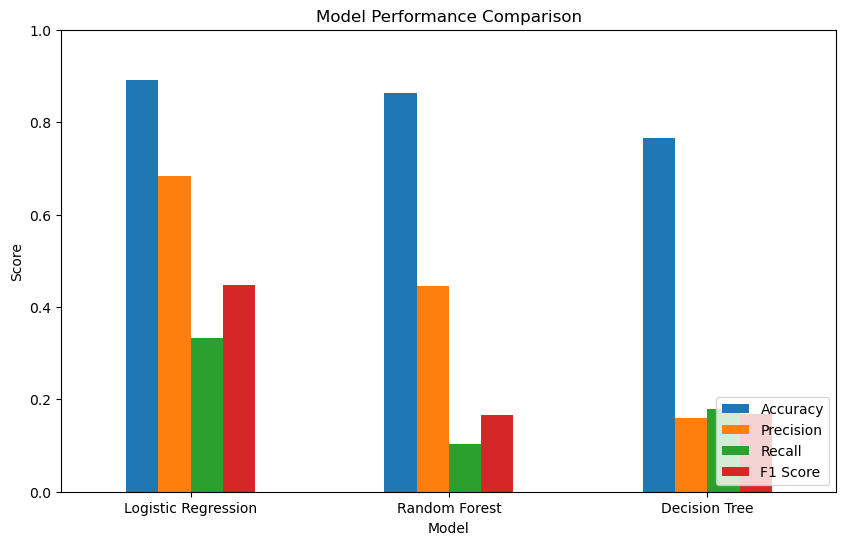

In [220]:
results_df.set_index("Model")[["Accuracy", "Precision", "Recall", "F1 Score"]].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.show()

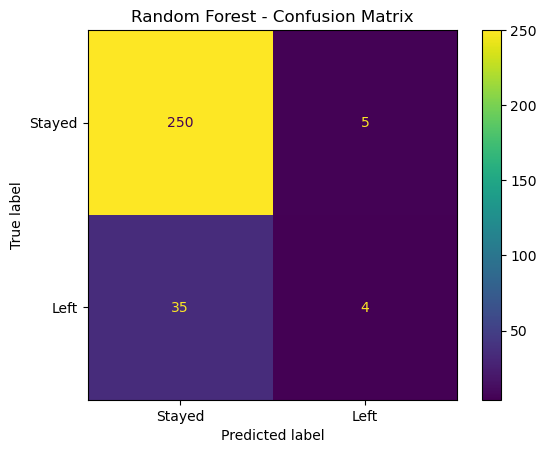

In [221]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rf,
    display_labels=["Stayed", "Left"]
)

plt.title("Random Forest - Confusion Matrix")
plt.show()

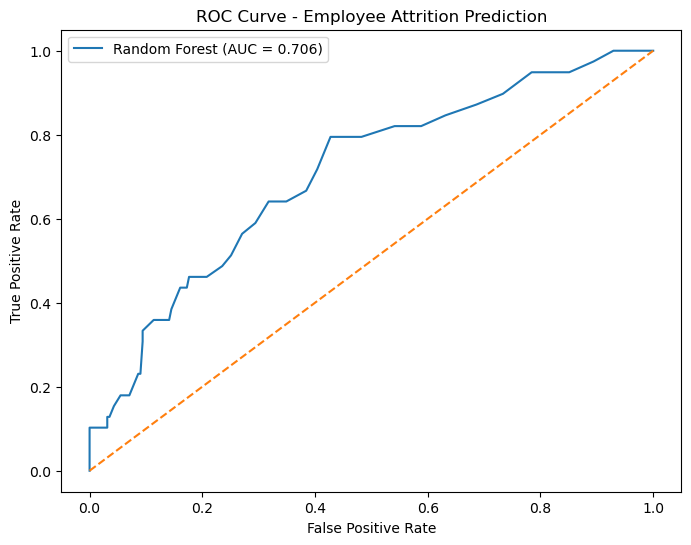

ROC-AUC: 0.7064353946706888


In [222]:
from sklearn.metrics import roc_curve, auc

y_prob_rf = rf.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob_rf)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))

plt.plot(fpr, tpr, label=f"Random Forest (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Employee Attrition Prediction")
plt.legend()
plt.show()

print("ROC-AUC:", roc_auc)

In [223]:
rf_balanced = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42
)

rf_balanced.fit(X_train, y_train)

y_pred_balanced = rf_balanced.predict(X_test)

In [224]:
print("Balanced Random Forest")
print("----------------------")

print("Accuracy:",
      accuracy_score(y_test, y_pred_balanced))

print("Precision:",
      precision_score(y_test, y_pred_balanced))

print("Recall:",
      recall_score(y_test, y_pred_balanced))

print("F1 Score:",
      f1_score(y_test, y_pred_balanced))

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_balanced,
    target_names=["Stayed", "Left"]
))

Balanced Random Forest
----------------------
Accuracy: 0.8809523809523809
Precision: 1.0
Recall: 0.10256410256410256
F1 Score: 0.18604651162790697

Classification Report:
              precision    recall  f1-score   support

      Stayed       0.88      1.00      0.94       255
        Left       1.00      0.10      0.19        39

    accuracy                           0.88       294
   macro avg       0.94      0.55      0.56       294
weighted avg       0.90      0.88      0.84       294



In [225]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

lr_balanced = LogisticRegression(
    class_weight="balanced",
    max_iter=2000,
    random_state=42
)

lr_balanced.fit(X_train, y_train)

y_pred_lr_balanced = lr_balanced.predict(X_test)

print("Balanced Logistic Regression")
print("--------------------------------")

print(classification_report(
    y_test,
    y_pred_lr_balanced,
    target_names=["Stayed", "Left"]
))

Balanced Logistic Regression
--------------------------------
              precision    recall  f1-score   support

      Stayed       0.93      0.73      0.82       255
        Left       0.26      0.62      0.37        39

    accuracy                           0.72       294
   macro avg       0.59      0.67      0.59       294
weighted avg       0.84      0.72      0.76       294



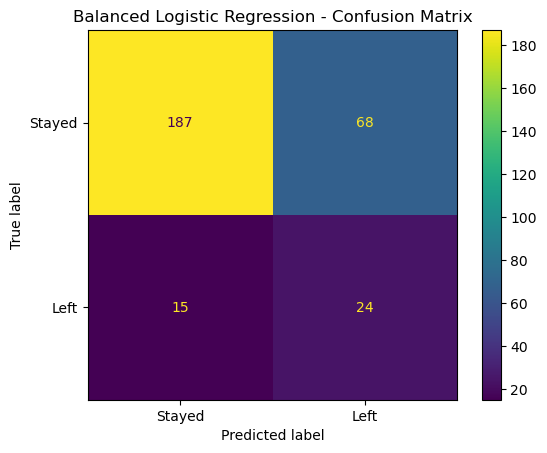

In [226]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_lr_balanced,
    display_labels=["Stayed", "Left"]
)

plt.title("Balanced Logistic Regression - Confusion Matrix")
plt.show()

In [227]:
print("Original Logistic Regression")
print("----------------------------")

print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall:", recall_score(y_test, y_pred_lr))
print("F1 Score:", f1_score(y_test, y_pred_lr))


print("\nBalanced Logistic Regression")
print("----------------------------")

print("Accuracy:", accuracy_score(y_test, y_pred_lr_balanced))
print("Precision:", precision_score(y_test, y_pred_lr_balanced))
print("Recall:", recall_score(y_test, y_pred_lr_balanced))
print("F1 Score:", f1_score(y_test, y_pred_lr_balanced))

Original Logistic Regression
----------------------------
Accuracy: 0.891156462585034
Precision: 0.6842105263157895
Recall: 0.3333333333333333
F1 Score: 0.4482758620689655

Balanced Logistic Regression
----------------------------
Accuracy: 0.717687074829932
Precision: 0.2608695652173913
Recall: 0.6153846153846154
F1 Score: 0.366412213740458


In [228]:
y_prob_lr = lr_balanced.predict_proba(X_test)[:, 1]

roc_auc_lr = roc_auc_score(y_test, y_prob_lr)

print("Logistic Regression ROC-AUC:", roc_auc_lr)

Logistic Regression ROC-AUC: 0.7585721468074409


In [229]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = np.arange(0.20, 0.71, 0.05)

threshold_results = []

for threshold in thresholds:

    y_pred_threshold = (y_prob_lr >= threshold).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(y_test, y_pred_threshold),
        "Recall": recall_score(y_test, y_pred_threshold),
        "F1 Score": f1_score(y_test, y_pred_threshold)
    })

threshold_df = pd.DataFrame(threshold_results)

threshold_df

,Threshold,Precision,Recall,F1 Score
0,0.20,0.186170,0.897436,0.308370
1,0.25,0.193939,0.820513,0.313725
2,0.30,0.200000,0.769231,0.317460
3,0.35,0.218750,0.717949,0.335329
4,0.40,0.232759,0.692308,0.348387
5,0.45,0.254902,0.666667,0.368794
6,0.50,0.260870,0.615385,0.366412
7,0.55,0.324324,0.615385,0.424779
8,0.60,0.349206,0.564103,0.431373
9,0.65,0.431373,0.564103,0.488889


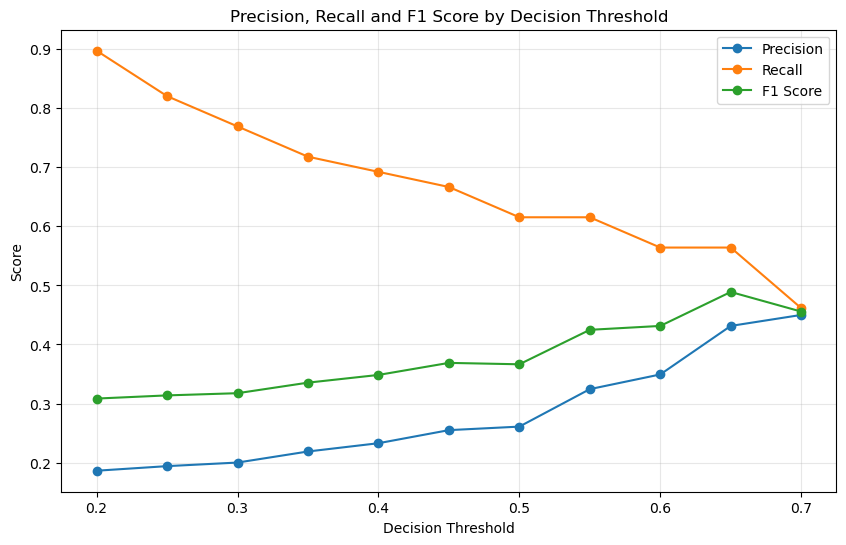

In [230]:
plt.figure(figsize=(10, 6))

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["F1 Score"],
    marker="o",
    label="F1 Score"
)

plt.xlabel("Decision Threshold")
plt.ylabel("Score")
plt.title("Precision, Recall and F1 Score by Decision Threshold")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [231]:
best_threshold = threshold_df.loc[
    threshold_df["F1 Score"].idxmax()
]

print("Best Threshold:")
print(best_threshold)

Best Threshold:
Threshold    0.650000
Precision    0.431373
Recall       0.564103
F1 Score     0.488889
Name: 9, dtype: float64


In [232]:
# Final evaluation using the optimized threshold

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# Apply optimized threshold
best_threshold = 0.65

y_pred_final = (y_prob_lr >= best_threshold).astype(int)

# Calculate final metrics
final_accuracy = accuracy_score(y_test, y_pred_final)
final_precision = precision_score(y_test, y_pred_final)
final_recall = recall_score(y_test, y_pred_final)
final_f1 = f1_score(y_test, y_pred_final)

print("FINAL MODEL PERFORMANCE")
print("=" * 30)
print(f"Threshold : {best_threshold}")
print(f"Accuracy  : {final_accuracy:.4f}")
print(f"Precision : {final_precision:.4f}")
print(f"Recall    : {final_recall:.4f}")
print(f"F1 Score  : {final_f1:.4f}")

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_final,
    target_names=["Stayed", "Left"]
))

FINAL MODEL PERFORMANCE
Threshold : 0.65
Accuracy  : 0.8435
Precision : 0.4314
Recall    : 0.5641
F1 Score  : 0.4889

Classification Report:
              precision    recall  f1-score   support

      Stayed       0.93      0.89      0.91       255
        Left       0.43      0.56      0.49        39

    accuracy                           0.84       294
   macro avg       0.68      0.73      0.70       294
weighted avg       0.86      0.84      0.85       294



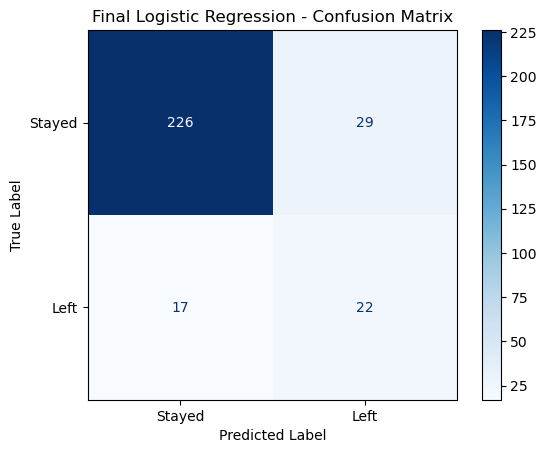

In [233]:
# Final Confusion Matrix

cm = confusion_matrix(y_test, y_pred_final)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Stayed", "Left"]
)

disp.plot(cmap="Blues")

plt.title("Final Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [234]:
# Feature Importance - Balanced Logistic Regression

# Get coefficients
coefficients = lr_balanced.coef_[0]

# Use original feature names
feature_names = X.columns

print("Number of coefficients:", len(coefficients))
print("Number of features:", len(feature_names))

Number of coefficients: 34
Number of features: 34


In [235]:
# Create feature importance dataframe

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients,
    "Absolute_Importance": abs(coefficients)
})

# Sort by importance
feature_importance = feature_importance.sort_values(
    by="Absolute_Importance",
    ascending=False
)

# Display top 15
top_features = feature_importance.head(15)

display(top_features)

,Feature,Coefficient,Absolute_Importance
30,YearsAtCompany,0.918278,0.918278
21,OverTime,0.842576,0.842576
31,YearsInCurrentRole,-0.722568,0.722568
33,YearsWithCurrManager,-0.537014,0.537014
16,MaritalStatus,0.473719,0.473719
19,NumCompaniesWorked,0.427956,0.427956
32,YearsSinceLastPromotion,0.405454,0.405454
15,JobSatisfaction,-0.393742,0.393742
9,EnvironmentSatisfaction,-0.386019,0.386019
27,TotalWorkingYears,-0.377010,0.377010


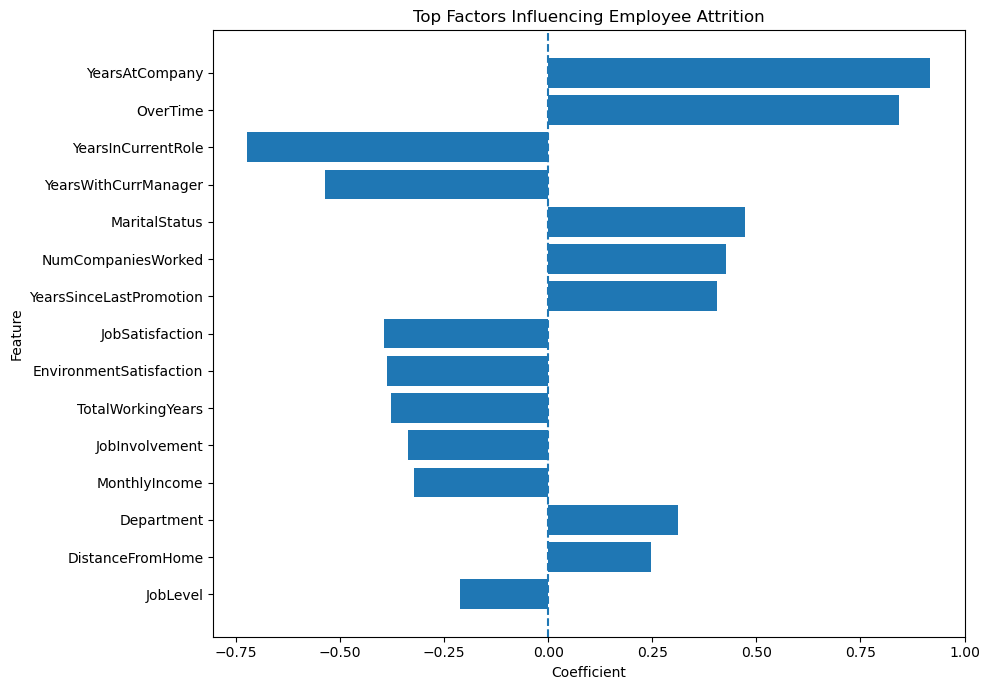

In [236]:
# Visualize Top 15 Features

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"][::-1],
    top_features["Coefficient"][::-1]
)

plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.title("Top Factors Influencing Employee Attrition")

plt.axvline(x=0, linestyle="--")

plt.tight_layout()
plt.show()

In [237]:
# Employee Attrition Prediction Function

def predict_attrition(employee_data):
    
    # Convert input into DataFrame
    employee_df = pd.DataFrame([employee_data])
    
    # Get probability of employee leaving
    probability = lr_balanced.predict_proba(employee_df)[0][1]
    
    # Apply optimized threshold
    prediction = int(probability >= 0.65)
    
    # Determine result
    if prediction == 1:
        result = "High Risk of Attrition"
    else:
        result = "Low Risk of Attrition"
    
    return {
        "Prediction": result,
        "Attrition Probability": round(probability * 100, 2)
    }

In [238]:
# Test prediction using one employee from the dataset

sample_employee = X.iloc[0].values.reshape(1, -1)

# Get probability
probability = lr_balanced.predict_proba(sample_employee)[0][1]

# Apply optimized threshold
prediction = int(probability >= 0.65)

# Display result
print("Employee Attrition Prediction")
print("=" * 35)

if prediction == 1:
    print("Prediction: High Risk of Attrition")
else:
    print("Prediction: Low Risk of Attrition")

print(f"Attrition Probability: {probability * 100:.2f}%")
print(f"Threshold Used: 0.65")

Employee Attrition Prediction
Prediction: High Risk of Attrition
Attrition Probability: 100.00%
Threshold Used: 0.65


In [239]:
import joblib

# Save the trained model
joblib.dump(lr_balanced, "employee_attrition_model.pkl")

print("Model saved successfully!")
print("File: employee_attrition_model.pkl")

Model saved successfully!
File: employee_attrition_model.pkl


In [240]:
import os

print("Model exists:", os.path.exists("employee_attrition_model.pkl"))

Model exists: True


In [241]:
import joblib

# Save feature names and prediction threshold
model_config = {
    "features": X.columns.tolist(),
    "threshold": 0.65
}

joblib.dump(model_config, "employee_attrition_config.pkl")

print("Model configuration saved successfully!")
print("Features saved:", len(model_config["features"]))
print("Threshold saved:", model_config["threshold"])

Model configuration saved successfully!
Features saved: 34
Threshold saved: 0.65


In [242]:
config = joblib.load("employee_attrition_config.pkl")

print("Number of features:", len(config["features"]))
print("Threshold:", config["threshold"])

Number of features: 34
Threshold: 0.65


In [243]:
# Final Business Insights

print("KEY BUSINESS INSIGHTS")
print("=" * 50)

print("\n1. Overall Attrition")
print("• 16.1% of employees have left the organization.")
print("• The dataset contains 1,470 employees.")

print("\n2. Overtime")
print("• Employees working overtime show substantially higher attrition.")
print("• Overtime is one of the strongest positive predictors in the model.")

print("\n3. Job Satisfaction")
print("• Employees with lower job satisfaction show higher attrition rates.")
print("• Job satisfaction has a negative coefficient in the final model.")

print("\n4. Environment Satisfaction")
print("• Lower workplace/environment satisfaction is associated with higher attrition.")

print("\n5. Business Travel")
print("• Frequent business travelers have considerably higher attrition than non-travel employees.")

print("\n6. Job Level")
print("• Entry-level employees show the highest attrition rate among job levels.")

print("\n7. Years at Company")
print("• Years at company is one of the strongest features in the final model.")

print("\n8. Career Progression")
print("• Years in current role, years with current manager, and years since last promotion")
print("  are important factors associated with employee attrition.")

KEY BUSINESS INSIGHTS

1. Overall Attrition
• 16.1% of employees have left the organization.
• The dataset contains 1,470 employees.

2. Overtime
• Employees working overtime show substantially higher attrition.
• Overtime is one of the strongest positive predictors in the model.

3. Job Satisfaction
• Employees with lower job satisfaction show higher attrition rates.
• Job satisfaction has a negative coefficient in the final model.

4. Environment Satisfaction
• Lower workplace/environment satisfaction is associated with higher attrition.

5. Business Travel
• Frequent business travelers have considerably higher attrition than non-travel employees.

6. Job Level
• Entry-level employees show the highest attrition rate among job levels.

7. Years at Company
• Years at company is one of the strongest features in the final model.

8. Career Progression
• Years in current role, years with current manager, and years since last promotion
  are important factors associated with employee attri

In [244]:
# Business Recommendations

print("BUSINESS RECOMMENDATIONS")
print("=" * 50)

recommendations = [
    "1. Monitor employees working overtime and evaluate workload distribution.",
    "2. Conduct regular employee satisfaction surveys and address low satisfaction scores.",
    "3. Review career progression opportunities for employees remaining in the same role.",
    "4. Strengthen promotion and internal mobility programs.",
    "5. Pay particular attention to entry-level employees and provide mentoring/support.",
    "6. Review the workload and travel requirements of frequently traveling employees.",
    "7. Use the attrition model as an early-warning system to identify high-risk employees.",
    "8. Combine model predictions with HR knowledge before taking retention actions."
]

for recommendation in recommendations:
    print(recommendation)

BUSINESS RECOMMENDATIONS
1. Monitor employees working overtime and evaluate workload distribution.
2. Conduct regular employee satisfaction surveys and address low satisfaction scores.
3. Review career progression opportunities for employees remaining in the same role.
4. Strengthen promotion and internal mobility programs.
5. Pay particular attention to entry-level employees and provide mentoring/support.
6. Review the workload and travel requirements of frequently traveling employees.
7. Use the attrition model as an early-warning system to identify high-risk employees.
8. Combine model predictions with HR knowledge before taking retention actions.


# 14. Conclusion

This project analyzed employee attrition using exploratory data analysis and machine learning.

The analysis identified several factors associated with employee attrition, including overtime, job satisfaction, business travel, job level, monthly income, age, and years at the company.

Multiple classification models were evaluated, including Logistic Regression, Random Forest, and Decision Tree. Because employee attrition is an imbalanced classification problem, model performance was evaluated using precision, recall, F1-score, ROC-AUC, and confusion matrices rather than relying solely on accuracy.

A class-weighted Logistic Regression model was selected and its decision threshold was optimized to improve the identification of employees at risk of attrition.

The final model achieved:

- **Accuracy:** 84.35%
- **Precision:** 43.14%
- **Recall:** 56.41%
- **F1 Score:** 48.89%
- **Decision Threshold:** 0.65

The model can serve as an analytical early-warning tool to help organizations identify employees who may be at higher risk of leaving. However, predictions should be combined with HR expertise and employee context rather than being used as the sole basis for employment decisions.